# Toeplitz operators — stationary kernels on regular grids

A Toeplitz matrix has constant diagonals: $K_{ij} = c_{|i-j|}$. Storage is $O(n)$ — just the first column $c$. Matvec is $O(n\log n)$ via FFT and the convolution theorem. For stationary kernels (RBF, Matérn, periodic) evaluated on a *regular 1-D grid*, the resulting covariance matrix is exactly Toeplitz, so we get a billion-fold storage saving and a thousand-fold compute saving over the dense form, with no approximation.

This is one of the cleanest "structure for free" wins in the catalog. Almost every classical signal-processing and time-series technique — autoregressive estimation, Wiener filtering, spectral analysis, fast power-spectrum density estimation — is, at heart, a Toeplitz solve.

## 0. Where Toeplitz structure shows up in geoscience

Wherever you sample a stationary process on a regular grid, you get a Toeplitz covariance. The relevant geoscience domains:

- **Time series of a single station / mooring / buoy**: tide gauges, pCO$_2$ moorings, soil-moisture probes, GPS displacements. Sampling cadence is regular (hourly / daily / monthly), and the stationary kernel matrix is Toeplitz directly.
- **1-D transects on a regular spatial grid**: along-track satellite-altimeter data (sea-surface height), ice-core depth profiles, vertical sounding profiles (radiosonde temperature vs altitude), DAS strain along a fibre. As long as the sampling spacing is uniform, the covariance is Toeplitz.
- **2-D stationary fields on a regular grid**: this is the workhorse. Sea-surface temperature on a lat × lon grid, atmospheric reanalyses, gridded CO$_2$ flux, surface displacements from InSAR — the covariance becomes `Kronecker(Toeplitz_x, Toeplitz_y)`, and 2-D matvec costs $O(N \log\sqrt N)$ instead of $O(N^2)$.
- **Spectral analysis & autocovariance estimation**: the periodogram, Welch's method, Lomb–Scargle, AR(p) fits — all of these compute or invert Toeplitz matrices implicitly. The Wiener–Khinchin theorem (covariance = inverse Fourier transform of the spectrum) is the same FFT trick formalized at the population level.
- **Stationary GP regression on equispaced data**: the entire toolkit of [Wood 2017] / [Kaufman & Sain 2008] for GP regression on regular grids relies on Toeplitz solves to scale to $n \sim 10^6$ time series points.

The catch: **stationarity is required** (kernel depends only on $|i-j|$, not on absolute position) and **regular sampling is required** (constant grid spacing). Drop either assumption — non-stationary process, irregular timestamps — and you fall back to dense $O(n^2)$ kernels (or 1.6 `MaskedOperator` for missing data on a regular grid).

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
from gaussx import (
    Kronecker,
    Toeplitz,
    logdet,
)

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(0)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})

## 1. The Toeplitz structure

A symmetric Toeplitz matrix is fully determined by its first column $c \in \mathbb{R}^n$:

```{math}
:label: eq:toeplitz-def
T_{ij} = c_{|i-j|}, \qquad T = \begin{bmatrix} c_0 & c_1 & c_2 & \cdots & c_{n-1} \\ c_1 & c_0 & c_1 & \cdots & c_{n-2} \\ c_2 & c_1 & c_0 & \cdots & c_{n-3} \\ \vdots & & & \ddots & \vdots \\ c_{n-1} & c_{n-2} & c_{n-3} & \cdots & c_0 \end{bmatrix}
```

Storage: $n$ floats instead of $n^2$. Symmetry is built in.

For a stationary kernel $k(\tau)$ evaluated on a regular grid $x_i = i \Delta x$, the entries are $K_{ij} = k(|i-j|\Delta x)$ — exactly Toeplitz with $c_d = k(d \Delta x)$. The first column *is* the kernel function sampled at the grid spacings.

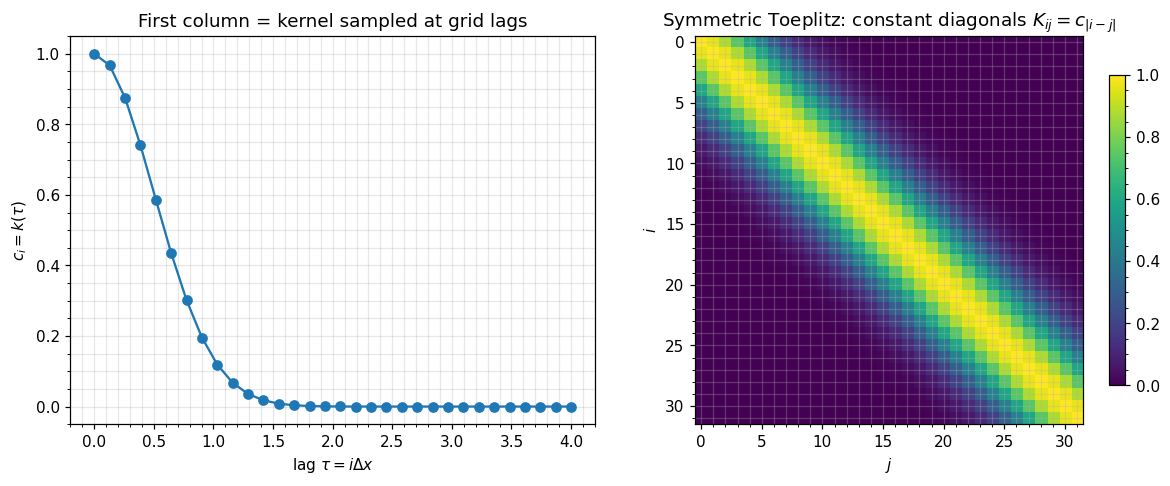

storage : 32 floats   (vs dense 1024)
saving  : 32x


In [2]:
# Stationary RBF kernel on a regular grid → Toeplitz
n = 32
grid = jnp.linspace(0.0, 4.0, n)
ell = 0.5
col = jnp.exp(-0.5 * (grid - grid[0])**2 / ell**2)

T = Toeplitz(col)
T_dense = T.as_matrix()

# Visualize the constant-diagonal structure
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(grid, col, "C0o-")
axes[0].set_xlabel(r"lag $\tau = i\Delta x$")
axes[0].set_ylabel(r"$c_i = k(\tau)$")
axes[0].set_title(r"First column = kernel sampled at grid lags")

im = axes[1].imshow(T_dense, cmap="viridis")
axes[1].set_title(r"Symmetric Toeplitz: constant diagonals $K_{ij}=c_{|i-j|}$")
axes[1].set_xlabel("$j$")
axes[1].set_ylabel("$i$")
plt.colorbar(im, ax=axes[1], shrink=0.8)
plt.tight_layout()
plt.show()

print(f"storage : {col.size} floats   (vs dense {T_dense.size})")
print(f"saving  : {T_dense.size / col.size:.0f}x")

## 2. Matvec via circulant embedding + FFT

The trick. Embed the $n\times n$ Toeplitz matrix into a $2(n-1)\times 2(n-1)$ *circulant* matrix by appending the reflected column:

```{math}
:label: eq:circulant-embed
\tilde c = (c_0, c_1, \dots, c_{n-1}, c_{n-2}, \dots, c_1) \in \mathbb{R}^{2n-2}
```

A circulant matrix is diagonalized by the Fourier basis, so multiplying it is element-wise multiplication in the frequency domain (the convolution theorem). The matvec on the original Toeplitz vector is:

```{math}
:label: eq:toeplitz-mv-fft
T v \;=\; \mathrm{IFFT}\!\Big(\mathrm{FFT}(\tilde c) \odot \mathrm{FFT}(\tilde v)\Big)\big[:n\big]
```

where $\tilde v$ is $v$ zero-padded to length $2n-2$. Cost: three FFTs of length $\sim 2n$, total $O(n\log n)$. Compared to dense matvec at $O(n^2)$ this is a thousand-fold speedup at $n=10^6$.

`gaussx.Toeplitz.mv` implements exactly this — let's verify.

In [3]:
v = jax.random.normal(jax.random.PRNGKey(1), (n,))

y_fft   = T.mv(v)
y_dense = T_dense @ v

err = jnp.linalg.norm(y_fft - y_dense)
print(f"FFT matvec vs dense    : err = {err:.2e}")

# logdet still works (gaussx falls back to dense Cholesky for now;
# Levinson-style O(n^2) algorithms are forthcoming).
T_pd = Toeplitz(col.at[0].add(1e-3), tags=lx.positive_semidefinite_tag)
ld_struct = float(logdet(T_pd))
ld_dense  = float(jnp.linalg.slogdet(T_pd.as_matrix())[1])
print(f"logdet (gaussx)        : {ld_struct:.6f}")
print(f"logdet (dense ref)     : {ld_dense:.6f}")

FFT matvec vs dense    : err = 3.91e-15


logdet (gaussx)        : -143.237465
logdet (dense ref)     : -143.237465


## 3. Cost table

| Operation | Dense | Toeplitz |
|---|---|---|
| Storage | $n^2$ | $n$ |
| Matvec | $O(n^2)$ | $O(n\log n)$ via FFT |
| Solve (exact) | $O(n^3)$ Cholesky | $O(n^2)$ Levinson–Durbin (fallback in `gaussx`: dense) |
| Solve (iterative) | $O(n^2)$ per CG iter | $O(n\log n)$ per CG iter |
| logdet (exact) | $O(n^3)$ Cholesky | $O(n^2)$ via Szegő-Levinson (fallback: dense) |
| logdet (asymptotic) | — | $\frac{n}{2\pi}\int\log\hat{c}(\omega)d\omega$ via FFT spectrum |

The current `gaussx` implementation gives you the *matvec* asymptotic for free. Exact $O(n^2)$ Toeplitz solve via Levinson is on the roadmap; until then, the practical pattern is **FFT-Toeplitz-matvec inside CG** (or any iterative Krylov solver), which is the right pattern at large $n$ anyway because $O(n^2)$ Levinson grows quadratically while CG with FFT matvec stays $O(n\log n)$ per iteration.

## 4. Asymptotic cost: dense vs Toeplitz

Theoretical FLOPs sweep, $n$ from $32$ to $2^{20}$. Note the $n=10^6$ point: dense matvec is $10^{12}$ flops (infeasible without distributed memory); Toeplitz matvec is $\sim 2\times 10^7$ flops (microseconds on a laptop). This is the gap that makes million-point regular-grid GP regression possible.

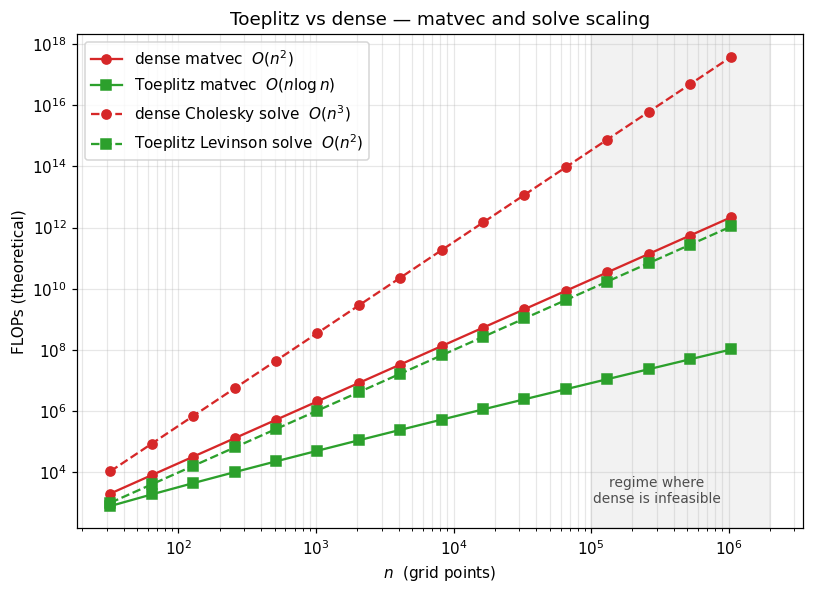

In [4]:
ns = np.array([2**k for k in range(5, 21)])  # 32 .. 1M
dense_mv  = 2 * ns**2
toep_mv   = 5 * ns * np.log2(ns)              # ~3 FFTs of length 2n
dense_solve = (1/3) * ns**3
toep_solve_levinson = ns**2

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.loglog(ns, dense_mv,             "C3-",  marker="o", label="dense matvec  $O(n^2)$")
ax.loglog(ns, toep_mv,              "C2-",  marker="s", label="Toeplitz matvec  $O(n\\log n)$")
ax.loglog(ns, dense_solve,          "C3--", marker="o", label="dense Cholesky solve  $O(n^3)$")
ax.loglog(ns, toep_solve_levinson,  "C2--", marker="s", label="Toeplitz Levinson solve  $O(n^2)$")
ax.axvspan(1e5, 2e6, color="grey", alpha=0.1)
ax.text(3e5, 1e3, "regime where\ndense is infeasible", ha="center", fontsize=9, color="0.3")
ax.set_xlabel(r"$n$  (grid points)")
ax.set_ylabel("FLOPs (theoretical)")
ax.set_title("Toeplitz vs dense — matvec and solve scaling")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 5. 2-D stationary kernels: `Kronecker(Toeplitz, Toeplitz)`

The composition is the headline geophysics application. A stationary kernel on a regular $n_x \times n_y$ grid factorizes as

```{math}
:label: eq:kron-toeplitz-2d
K = K_x \otimes K_y, \qquad K_x \in \mathbb{R}^{n_x\times n_x}\;\text{Toeplitz}, \quad K_y \in \mathbb{R}^{n_y\times n_y}\;\text{Toeplitz}
```

Storage drops from $N^2 = (n_x n_y)^2$ to $n_x + n_y$. Matvec costs $O(N(\log n_x + \log n_y))$ — i.e. $O(N\log\sqrt N)$ — via the Kronecker vec-trick wrapping two FFT-Toeplitz matvecs.

This is the structure of essentially every 2-D gridded reanalysis covariance (SST, surface temperature, atmospheric pressure, soil moisture, gridded CO$_2$ flux). When you see a paper claiming "we scale to $10^6$ spatial points without approximation", the operator is almost always `Kronecker(Toeplitz_x, Toeplitz_y)`.

In [5]:
nx, ny = 32, 24
gx = jnp.linspace(0, 4, nx)
gy = jnp.linspace(0, 3, ny)
ell_x, ell_y = 0.5, 0.4
col_x = jnp.exp(-0.5 * (gx - gx[0])**2 / ell_x**2)
col_y = jnp.exp(-0.5 * (gy - gy[0])**2 / ell_y**2)

T_x = Toeplitz(col_x, tags=lx.positive_semidefinite_tag)
T_y = Toeplitz(col_y, tags=lx.positive_semidefinite_tag)
K_2d = Kronecker(T_x, T_y)
N = nx * ny

# Verify against the dense reference
K_dense = jnp.kron(T_x.as_matrix(), T_y.as_matrix())
v = jax.random.normal(jax.random.PRNGKey(2), (N,))
err = jnp.linalg.norm(K_2d.mv(v) - K_dense @ v)

print(f"grid           : {nx} x {ny} = {N} points")
print(f"matvec error   : {err:.2e}")
print(f"Kron-Toeplitz storage : {col_x.size + col_y.size} floats")
print(f"Dense storage         : {N*N} floats  ({N*N / (col_x.size + col_y.size):.0f}x more)")

grid           : 32 x 24 = 768 points
matvec error   : 8.60e-14
Kron-Toeplitz storage : 56 floats
Dense storage         : 589824 floats  (10533x more)


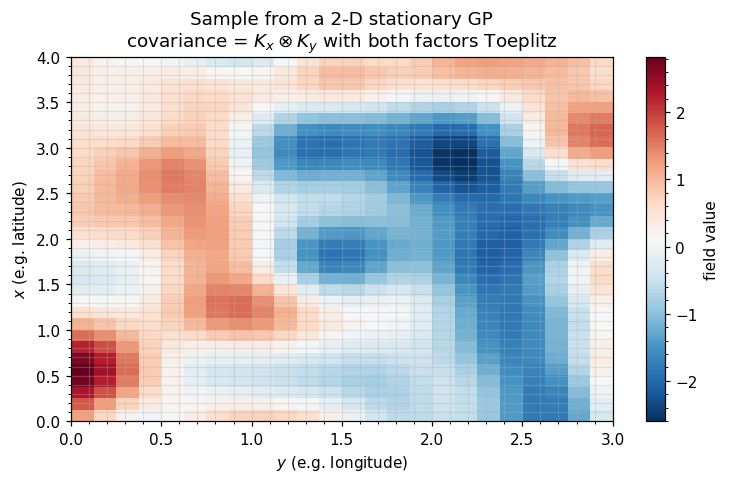

In [6]:
# Visualize: a sample drawn from the 2-D stationary GP using the Kron-Toeplitz operator.
# Sample by drawing in eigenbasis: f = Q diag(sqrt(eigs)) z, where Q is Q_x ⊗ Q_y.
la, Qx = jnp.linalg.eigh(T_x.as_matrix())
mu, Qy = jnp.linalg.eigh(T_y.as_matrix())
eigs_2d = (la[:, None] * mu[None, :])  # outer product of factor spectra
z = jax.random.normal(jax.random.PRNGKey(3), (nx, ny))
f = Qx @ (jnp.sqrt(jnp.clip(eigs_2d, 0)) * (Qx.T @ z @ Qy)) @ Qy.T

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(f, extent=[gy[0], gy[-1], gx[0], gx[-1]], origin="lower",
               cmap="RdBu_r", aspect="auto")
ax.set_xlabel("$y$ (e.g. longitude)")
ax.set_ylabel("$x$ (e.g. latitude)")
ax.set_title("Sample from a 2-D stationary GP\n"
             r"covariance = $K_x \otimes K_y$ with both factors Toeplitz")
plt.colorbar(im, ax=ax, label="field value")
plt.tight_layout()
plt.show()

## 6. Caveats — when Toeplitz fails

Three sharp edges to watch for in real geoscience workflows:

- **Non-stationarity**. If the kernel depends on absolute position $k(x_i, x_j)$ rather than just lag $k(|i-j|)$, the matrix is *not* Toeplitz. Examples: input-dependent lengthscales (heteroscedastic kernels), spatially varying anisotropy, locally adaptive RBF. Workaround: locally stationary patches with a `BlockDiag(Toeplitz, Toeplitz, ...)`, or warp the input space before applying a stationary kernel.

- **Irregular sampling**. Toeplitz requires *constant* grid spacing. A tide-gauge series with missing observations is no longer Toeplitz — but it *is* a Toeplitz matrix on the full regular grid restricted to the observed indices, which is exactly what `MaskedOperator` (notebook 1.6) handles. For genuinely irregular timestamps (event-driven data, asynchronous moorings), Toeplitz is gone and you fall back to dense or to inducing-point approximations.

- **2-D irregular grids**. The Kronecker × Toeplitz trick requires *both* axes to be regular. An ocean reanalysis on a regular lat/lon grid is fine; an unstructured triangular mesh from a finite-element ocean model (e.g. FESOM, MPAS) is not. For unstructured meshes use the GMRF / sparse-precision route instead (1.5 BlockTriDiag, future 4.C).

The next notebook (1.5 BlockTriDiag) covers the *temporal-Markov* alternative to Toeplitz: instead of an $O(n\log n)$ matvec for stationary covariances, you get an $O(n)$ solve for sparse-precision (Markov) covariances. The two structures are dual and often combined.